# EDA German Credit

Разведочный анализ датасета кредитного скоринга.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

## 1. Загрузка данных и базовая информация

In [2]:
data_path = Path('..') / 'data' / 'raw' / 'german_credit.csv'
df = pd.read_csv(data_path)

print('Shape:', df.shape)
display(df.head())
display(df.dtypes.to_frame('dtype'))
display(df.describe(include='all').T.head(25))
display(df.isnull().sum().to_frame('null_count').T)

Shape: (1000, 21)


,Status,Duration,History,Purpose,Amount,Savings,Employment,InstallmentRate,PersonalStatus,Guarantors,...,Property,Age,OtherInstallments,Housing,ExistingCredits,Job,Dependents,Phone,Foreign,Target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


,dtype
Status,object
Duration,int64
History,object
Purpose,object
Amount,int64
Savings,object
Employment,object
InstallmentRate,int64
PersonalStatus,object
Guarantors,object


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Status,1000,4,A14,394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
History,1000,5,A32,530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Purpose,1000,10,A43,280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Savings,1000,5,A61,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Employment,1000,5,A73,339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InstallmentRate,1000.0,NaN,NaN,NaN,2.973,1.118715,1.0,2.0,3.0,4.0,4.0
PersonalStatus,1000,4,A93,548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Guarantors,1000,3,A101,907,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Status,Duration,History,Purpose,Amount,Savings,Employment,InstallmentRate,PersonalStatus,Guarantors,...,Property,Age,OtherInstallments,Housing,ExistingCredits,Job,Dependents,Phone,Foreign,Target
null_count,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Вывод: данные имеют фиксированный размер, пропуски отсутствуют, присутствует смесь категориальных и числовых признаков.

## 2. Анализ целевой переменной Target

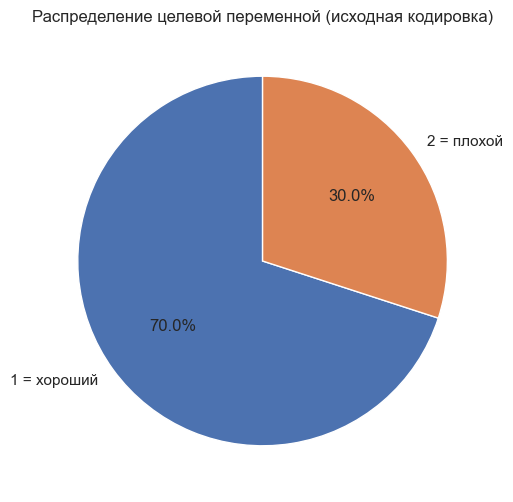

Target01
0    0.7
1    0.3
Name: Доля классов, dtype: float64

In [3]:
target_raw = df['Target'].value_counts().sort_index()
plt.figure(figsize=(6, 6))
plt.pie(target_raw.values, labels=['1 = хороший', '2 = плохой'], autopct='%1.1f%%', startangle=90)
plt.title('Распределение целевой переменной (исходная кодировка)')
plt.show()

df['Target01'] = df['Target'].map({1: 0, 2: 1})
df['Target01'].value_counts(normalize=True).rename('Доля классов')

Вывод: классы умеренно несбалансированы, что требует учета при обучении моделей.

## 3. Распределение числовых признаков

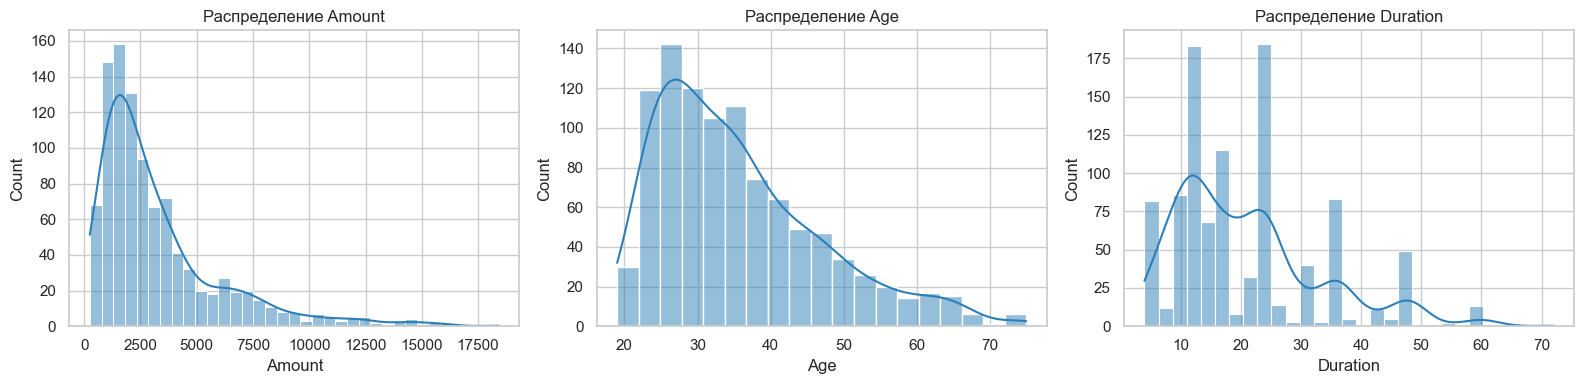

In [4]:
num_cols = ['Amount', 'Age', 'Duration']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='#2c7fb8')
    ax.set_title(f'Распределение {col}')
plt.tight_layout()
plt.show()

Вывод: признаки имеют неоднородные шкалы и асимметричные распределения, поэтому масштабирование уместно.

## 4. Анализ категориальных признаков

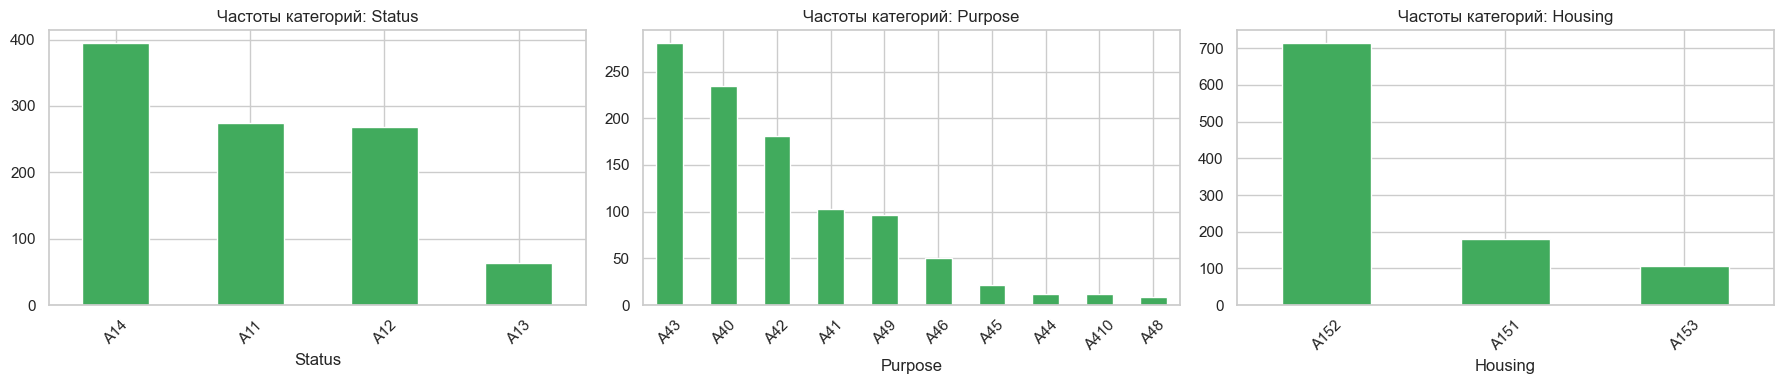

In [5]:
cat_cols = ['Status', 'Purpose', 'Housing']
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, color='#41ab5d')
    ax.set_title(f'Частоты категорий: {col}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Вывод: распределения категорий неравномерны, редкие категории могут влиять на устойчивость модели.

## 5. Корреляционная матрица числовых признаков

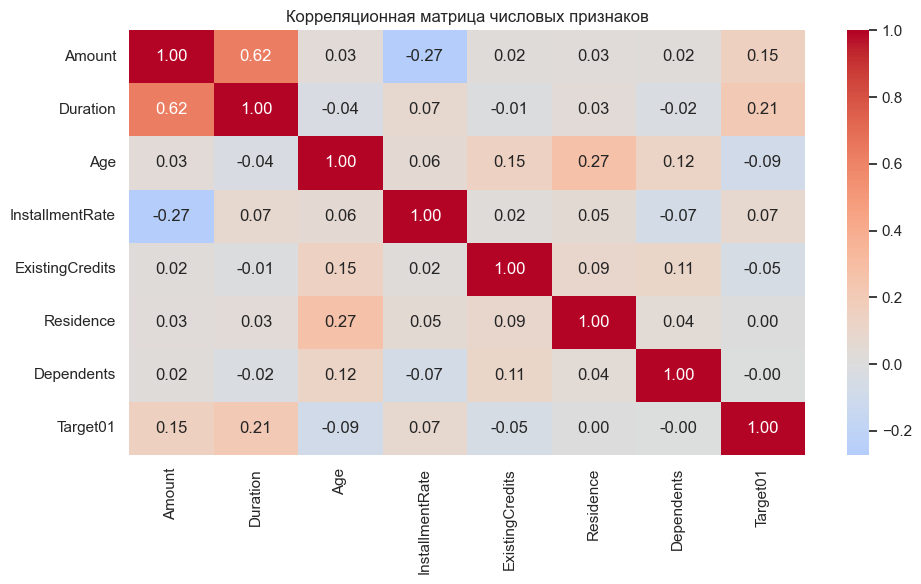

In [6]:
corr_cols = ['Amount', 'Duration', 'Age', 'InstallmentRate', 'ExistingCredits', 'Residence', 'Dependents', 'Target01']
corr = df[corr_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.show()

Вывод: линейные зависимости между числовыми признаками в основном умеренные, сильной мультиколлинеарности не наблюдается.

## 6. Боксплоты Amount и Duration по Target

C:\Users\alexf\AppData\Local\Temp\ipykernel_27452\2933312285.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target01', y='Amount', ax=axes[0], palette='Set2')
C:\Users\alexf\AppData\Local\Temp\ipykernel_27452\2933312285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target01', y='Duration', ax=axes[1], palette='Set3')


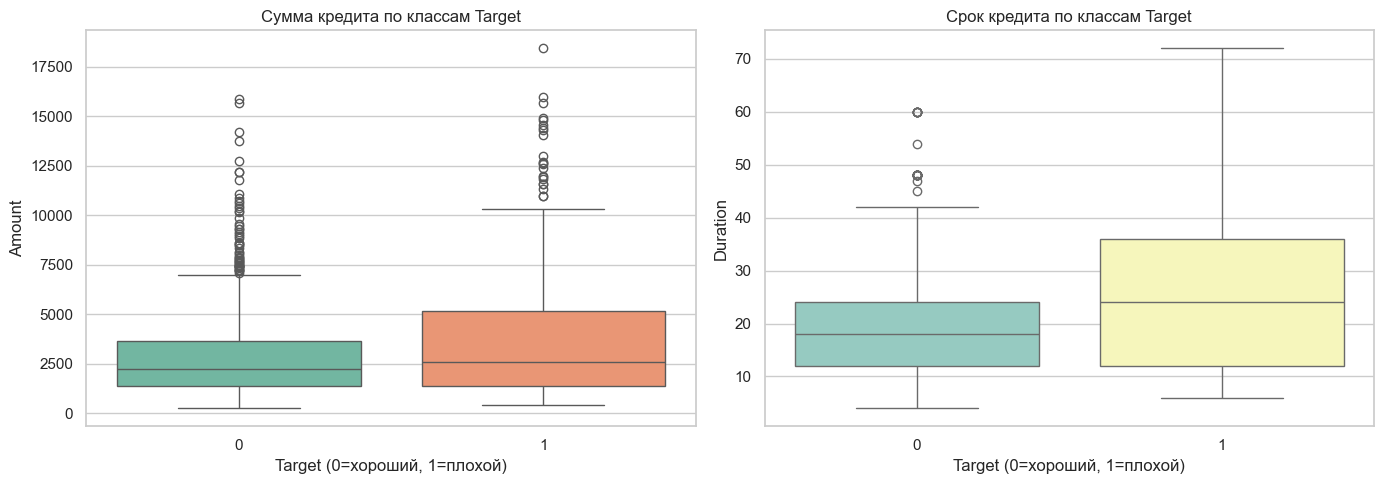

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Target01', y='Amount', ax=axes[0], palette='Set2')
axes[0].set_title('Сумма кредита по классам Target')
axes[0].set_xlabel('Target (0=хороший, 1=плохой)')

sns.boxplot(data=df, x='Target01', y='Duration', ax=axes[1], palette='Set3')
axes[1].set_title('Срок кредита по классам Target')
axes[1].set_xlabel('Target (0=хороший, 1=плохой)')

plt.tight_layout()
plt.show()

Вывод: у более рискованных клиентов чаще встречаются большие суммы и более длинные сроки кредитования.

## 7. Общий итог

Данные подходят для построения интерпретируемых моделей скоринга. На следующем этапе выполняется предобработка, учет дисбаланса классов и сравнение baseline-моделей.